# Análisis del Mercado Inmobiliario Japonés — Valor del Suelo

**Objetivo**: identificar el *land value floor* — el punto donde el precio de venta de una propiedad se explica íntegramente por el valor del terreno y no por la construcción.

**Método**: regresión lineal múltiple sobre `log(TradePrice)` con `BuildingAge`, `Area`, `TimeToNearestStation` y dummies de `Structure`, `CityPlanning` y `Prefecture`.

**Datos**: `data/clean/japan_clean.csv` generado por `clean_data.py` a partir de los 47 CSVs de MLIT Japón (2006–2019).

## Celda 0 — Imports

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

FIG_DIR = Path('figures')
RES_DIR = Path('results')
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

## Celda 1 — Cargar datos

In [2]:
df = pd.read_csv('data/clean/japan_clean.csv')

print(f'Registros:   {len(df):,}')
print(f'Prefecturas: {df["Prefecture"].nunique()}')
print(f'Municipios:  {df["Municipality"].nunique()}')
print(f'Período:     {df["Year"].min()}–{df["Year"].max()}')
df.describe()

Registros:   838,183
Prefecturas: 47
Municipios:  1499
Período:     2005–2019


,MunicipalityCode,TradePrice,Area,BuildingAge,BuildingYear,Year,Quarter,TimeToNearestStation,CoverageRatio,FloorAreaRatio,PrewarBuilding
count,838183.000000,8.381830e+05,838183.000000,838183.000000,838183.000000,838183.000000,838183.000000,838183.000000,822012.000000,822012.000000,838183.000000
mean,19735.093452,3.665269e+07,202.900751,16.819594,1996.053294,2012.872888,2.481037,13.838509,59.127592,187.415159,0.002241
std,10482.235546,5.186223e+07,202.522899,16.842608,16.861677,3.744169,1.106345,7.118773,9.748655,88.276848,0.047282
min,1101.000000,5.000000e+05,10.000000,0.000000,1945.000000,2005.000000,1.000000,0.000000,30.000000,50.000000,0.000000
25%,12222.000000,1.500000e+07,100.000000,0.000000,1982.000000,2010.000000,1.000000,8.000000,60.000000,100.000000,0.000000
50%,14216.000000,2.700000e+07,145.000000,14.000000,1998.000000,2013.000000,2.000000,13.000000,60.000000,200.000000,0.000000
75%,27210.000000,4.000000e+07,220.000000,30.000000,2011.000000,2016.000000,3.000000,19.000000,60.000000,200.000000,0.000000
max,47208.000000,1.000000e+09,1900.000000,74.000000,2019.000000,2019.000000,4.000000,29.000000,80.000000,1300.000000,1.000000


## Celda 2 — EDA básico

Distribuciones de las variables clave: antigüedad, precio (en log), precio mediano por antigüedad y conteo por tipo de estructura.

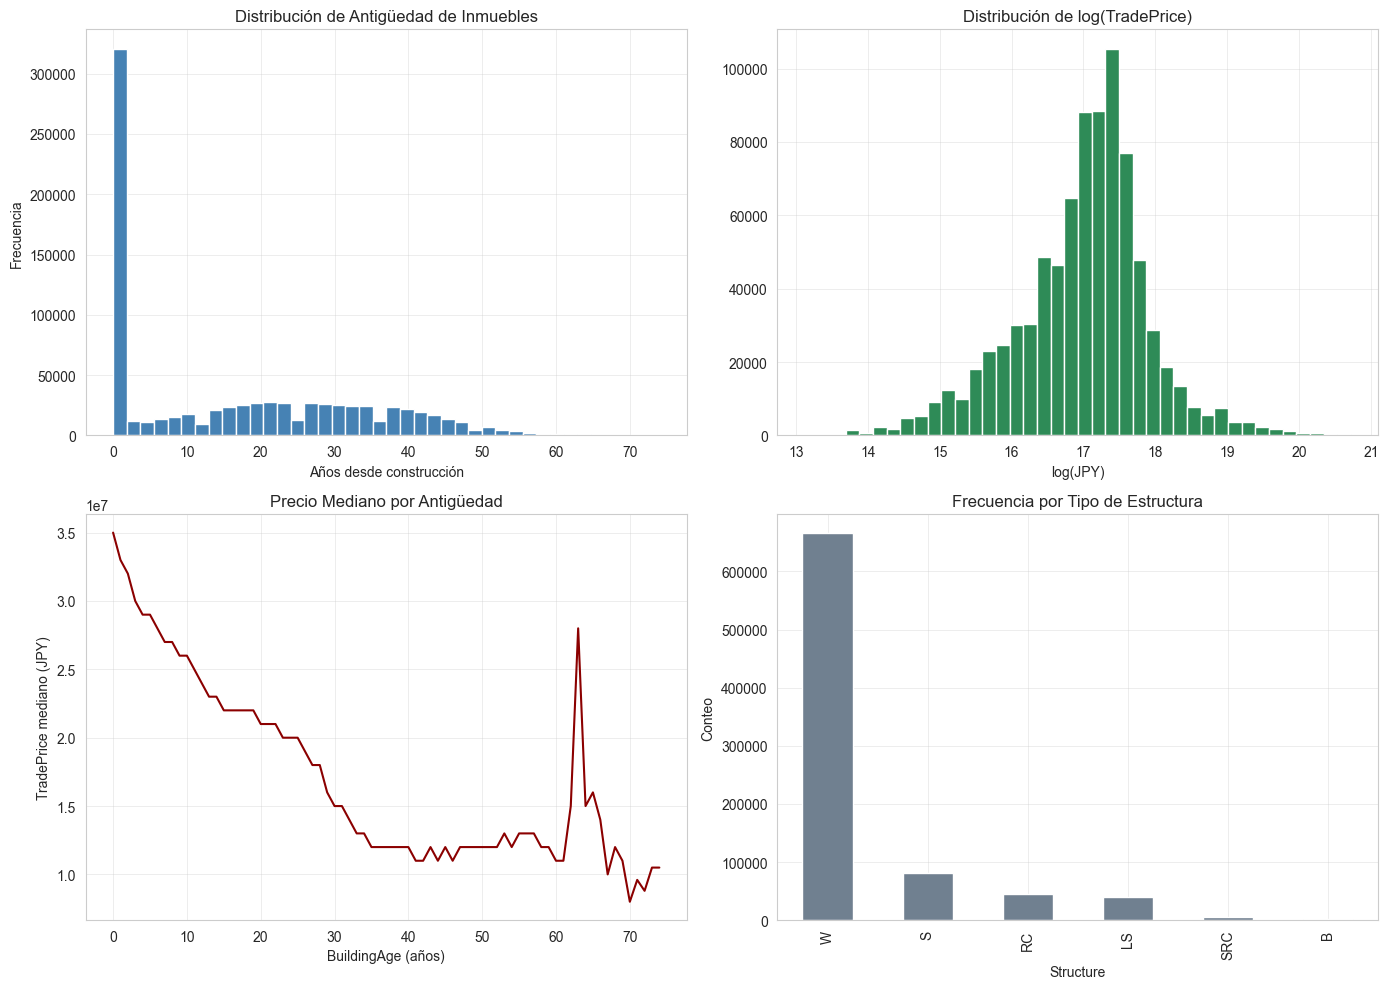

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de BuildingAge
axes[0, 0].hist(df['BuildingAge'], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribución de Antigüedad de Inmuebles')
axes[0, 0].set_xlabel('Años desde construcción')
axes[0, 0].set_ylabel('Frecuencia')

# Distribución de log(TradePrice)
axes[0, 1].hist(np.log(df['TradePrice']), bins=40, color='seagreen', edgecolor='white')
axes[0, 1].set_title('Distribución de log(TradePrice)')
axes[0, 1].set_xlabel('log(JPY)')

# Precio mediano por antigüedad
median_by_age = df.groupby('BuildingAge')['TradePrice'].median()
axes[1, 0].plot(median_by_age.index, median_by_age.values, color='darkred')
axes[1, 0].set_title('Precio Mediano por Antigüedad')
axes[1, 0].set_xlabel('BuildingAge (años)')
axes[1, 0].set_ylabel('TradePrice mediano (JPY)')

# Conteo por tipo de estructura
df['Structure'].value_counts().plot(kind='bar', ax=axes[1, 1], color='slategray')
axes[1, 1].set_title('Frecuencia por Tipo de Estructura')
axes[1, 1].set_xlabel('Structure')
axes[1, 1].set_ylabel('Conteo')

plt.tight_layout()
plt.savefig(FIG_DIR / '02_eda_basico.png', dpi=120, bbox_inches='tight')
plt.show()

## Celda 3 — Feature Engineering

Transformación logarítmica de la variable dependiente y creación de variables dummy para `Structure`, `CityPlanning` y `Prefecture`.

In [4]:
# Variable dependiente: log estabiliza la varianza en precios sesgados
df['log_price'] = np.log(df['TradePrice'])

# Dummies para variables categóricas
df_model = pd.get_dummies(
    df,
    columns=['Structure', 'CityPlanning', 'Prefecture'],
    drop_first=True,
)

feature_cols = (
    ['BuildingAge', 'Area', 'TimeToNearestStation']
    + [c for c in df_model.columns if c.startswith('Structure_')]
    + [c for c in df_model.columns if c.startswith('CityPlanning_')]
    + [c for c in df_model.columns if c.startswith('Prefecture_')]
)

X = df_model[feature_cols].astype(float)
y = df_model['log_price']

print(f'Features:           {len(feature_cols)}')
print(f'Registros en modelo: {len(X):,}')
print(f'  - numéricos:       3 (BuildingAge, Area, TimeToNearestStation)')
print(f'  - Structure:       {sum(c.startswith("Structure_") for c in feature_cols)}')
print(f'  - CityPlanning:    {sum(c.startswith("CityPlanning_") for c in feature_cols)}')
print(f'  - Prefecture:      {sum(c.startswith("Prefecture_") for c in feature_cols)}')

Features:           69
Registros en modelo: 838,183
  - numéricos:       3 (BuildingAge, Area, TimeToNearestStation)
  - Structure:       5
  - CityPlanning:    15
  - Prefecture:      46


## Celda 4 — Modelo con sklearn

Estilo del notebook de la maestra: `LinearRegression` con `train_test_split`, R² y RMSE.

In [5]:
import time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

start_sklearn = time.time()
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)
elapsed_sklearn = time.time() - start_sklearn

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
coef_age = model.coef_[feature_cols.index('BuildingAge')]

print(f'R²  (test): {r2:.4f}')
print(f'RMSE (log): {rmse:.4f}')
print(f'Coeficiente de BuildingAge: {coef_age:.6f}')
print(f'Intercepto:                 {model.intercept_:.4f}')
print(f'Interpretación: por cada año adicional, el precio cambia ~{coef_age*100:.2f}%')
print()
print(f'Velocidad sklearn : {len(X_train) / elapsed_sklearn:,.0f} filas/segundo')
print(f'Tiempo sklearn    : {elapsed_sklearn:.2f} segundos')


R²  (test): 0.5845
RMSE (log): 0.5957
Coeficiente de BuildingAge: -0.025727
Intercepto:                 17.2748
Interpretación: por cada año adicional, el precio cambia ~-2.57%

Velocidad sklearn : 319,480 filas/segundo
Tiempo sklearn    : 2.10 segundos


## Celda 5 — Interpretación OLS detallada con statsmodels

`statsmodels` aporta lo que `sklearn` no: p-valores, intervalos de confianza y errores estándar para cada coeficiente.

In [6]:
import time

start_ols = time.time()
X_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_const).fit()
elapsed_ols = time.time() - start_ols

print(f'Velocidad OLS statsmodels : {len(X_train) / elapsed_ols:,.0f} filas/segundo')
print(f'Tiempo OLS statsmodels    : {elapsed_ols:.2f} segundos')
print()

# Resumen completo
print(ols_model.summary())

coef_age = ols_model.params['BuildingAge']
pval_age = ols_model.pvalues['BuildingAge']
ci_age   = ols_model.conf_int().loc['BuildingAge']

print('\n' + '=' * 60)
print(f'Coeficiente BuildingAge: {coef_age:.6f}  (p={pval_age:.4e})')
print(f'IC 95%: [{ci_age[0]:.6f}, {ci_age[1]:.6f}]')
print(f'Por cada año adicional de antigüedad, el precio cae ~{abs(coef_age)*100:.2f}%')


Velocidad OLS statsmodels : 139,489 filas/segundo
Tiempo OLS statsmodels    : 4.81 segundos

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                 1.384e+04
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        21:26:09   Log-Likelihood:            -6.0044e+05
No. Observations:              670546   AIC:                         1.201e+06
Df Residuals:                  670476   BIC:                         1.202e+06
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                        coef    std err          t      P>|t|      [0

In [7]:
# Exportar tabla de coeficientes a CSV para la tesis
coef_table = pd.DataFrame({
    'coef':    ols_model.params,
    'std_err': ols_model.bse,
    'p_value': ols_model.pvalues,
    'ci_low':  ols_model.conf_int()[0],
    'ci_high': ols_model.conf_int()[1],
})
coef_table.to_csv(RES_DIR / 'coeficientes_ols.csv')
print(f'Tabla guardada en {RES_DIR / "coeficientes_ols.csv"}')
coef_table.head(10)

Tabla guardada en results\coeficientes_ols.csv


,coef,std_err,p_value,ci_low,ci_high
const,17.274832,0.017279,0.000000e+00,17.240965,17.308699
BuildingAge,-0.025727,0.000046,0.000000e+00,-0.025818,-0.025637
Area,0.001419,0.000004,0.000000e+00,0.001411,0.001428
TimeToNearestStation,-0.011322,0.000110,0.000000e+00,-0.011538,-0.011105
Structure_LS,0.329486,0.017128,1.925031e-82,0.295915,0.363056
Structure_RC,0.942596,0.017102,0.000000e+00,0.909077,0.976115
Structure_S,0.439402,0.016982,1.497653e-147,0.406119,0.472686
Structure_SRC,1.191035,0.019473,0.000000e+00,1.152868,1.229202
Structure_W,0.050370,0.016837,2.775851e-03,0.017369,0.083371
CityPlanning_Category I Exclusively Medium-high Residential Zone,-0.031039,0.002398,2.487449e-38,-0.035739,-0.026340


## Celda 6 — Curva de depreciación por tipo de estructura

Para cada tipo de estructura, simulamos el precio predicho variando `BuildingAge` y manteniendo el resto de features en su mediana. Esto aísla el efecto de la antigüedad sobre el precio.

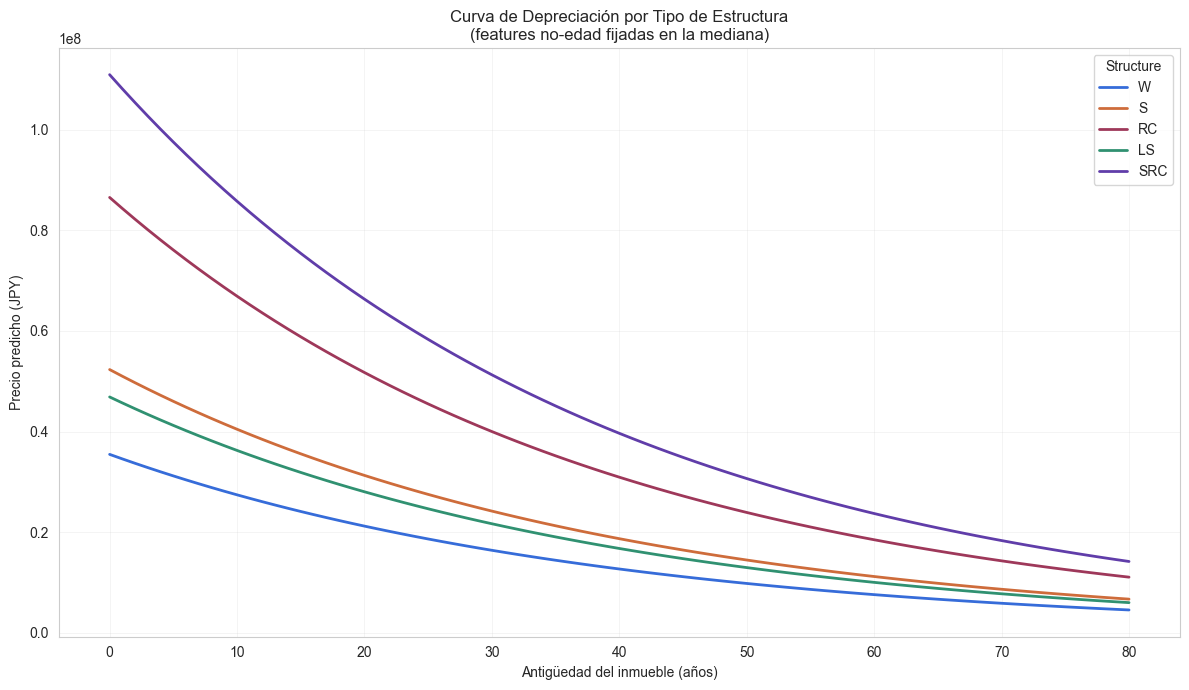

In [8]:
ages = np.arange(0, 81, 1)
structures = df['Structure'].value_counts().index[:5].tolist()

# Plantilla con todas las features en su mediana / cero (dummies)
median_row = X.median()

fig, ax = plt.subplots(figsize=(12, 7))

for struct in structures:
    X_sim = pd.DataFrame([median_row.values] * len(ages), columns=X.columns)
    X_sim['BuildingAge'] = ages

    # Apagar todas las dummies de Structure y prender la del struct actual
    for c in X_sim.columns:
        if c.startswith('Structure_'):
            X_sim[c] = 0.0
    dummy_col = f'Structure_{struct}'
    if dummy_col in X_sim.columns:
        X_sim[dummy_col] = 1.0
    # Si struct es la categoría base (drop_first), todas las dummies quedan en 0

    log_pred = model.predict(X_sim)
    price_pred = np.exp(log_pred)
    ax.plot(ages, price_pred, label=struct, linewidth=2)

ax.set_xlabel('Antigüedad del inmueble (años)')
ax.set_ylabel('Precio predicho (JPY)')
ax.set_title('Curva de Depreciación por Tipo de Estructura\n(features no-edad fijadas en la mediana)')
ax.legend(title='Structure')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_depreciacion_por_estructura.png', dpi=120, bbox_inches='tight')
plt.show()

## Celda 7 — Land Value Floor por municipio / prefectura

Para encontrar el piso de valor del suelo usamos un proxy empírico: la **mediana del precio por m² entre inmuebles muy antiguos** (`BuildingAge ≥ 50`). En este rango la construcción ya casi no contribuye al precio, por lo que lo que queda es esencialmente el valor del terreno.

Filtramos a municipios con al menos 10 transacciones para evitar rankings dominados por outliers.

In [9]:
old_properties = df[df['BuildingAge'] >= 50]

land_value_proxy = (
    old_properties
    .groupby(['Prefecture', 'Municipality'])
    .agg(
        median_price=('TradePrice', 'median'),
        count=('TradePrice', 'count'),
        median_area=('Area', 'median'),
    )
    .reset_index()
)
land_value_proxy['price_per_m2'] = (
    land_value_proxy['median_price'] / land_value_proxy['median_area']
)
land_value_proxy = land_value_proxy[land_value_proxy['count'] >= 10]

land_value_proxy.to_csv(RES_DIR / 'land_value_floor_por_municipio.csv', index=False)

print(f'Municipios con muestra suficiente (≥10 transacciones, edad ≥50): {len(land_value_proxy)}')
print(f'\n— TOP 20 más accesibles (precio/m² más bajo) —')
display(land_value_proxy.sort_values('price_per_m2').head(20))

print(f'\n— TOP 10 más caros (precio/m² más alto) —')
display(land_value_proxy.sort_values('price_per_m2', ascending=False).head(10))

Municipios con muestra suficiente (≥10 transacciones, edad ≥50): 549

— TOP 20 más accesibles (precio/m² más bajo) —


,Prefecture,Municipality,median_price,count,median_area,price_per_m2
1119,Tokushima Prefecture,Yoshinogawa City,3150000.0,12,555.0,5675.675676
363,Hokkaido,Iwamizawa City,1850000.0,12,275.0,6727.272727
497,Ishikawa Prefecture,Kahoku City,3250000.0,12,480.0,6770.833333
409,Hokkaido,Takikawa City,1800000.0,10,245.0,7346.938776
66,Akita Prefecture,Kazuno City,2500000.0,13,330.0,7575.757576
1185,Toyama Prefecture,"Kamiichi Town,Nakaniikawa County",1700000.0,10,220.0,7727.272727
385,Hokkaido,Nayoro City,2200000.0,26,280.0,7857.142857
82,Aomori Prefecture,Goshogawara City,2250000.0,10,270.0,8333.333333
680,Mie Prefecture,Iga City,2800000.0,20,300.0,9333.333333
756,Nagano Prefecture,Komoro City,2000000.0,10,210.0,9523.809524



— TOP 10 más caros (precio/m² más alto) —


,Prefecture,Municipality,median_price,count,median_area,price_per_m2
1127,Tokyo,Chuo Ward,130000000.0,101,65.0,2.000000e+06
1151,Tokyo,Minato Ward,130000000.0,69,80.0,1.625000e+06
1125,Tokyo,Chiyoda Ward,115000000.0,44,75.0,1.533333e+06
891,Osaka Prefecture,"Chuo Ward,Osaka City",76000000.0,130,82.5,9.212121e+05
1162,Tokyo,Shibuya Ward,89000000.0,77,105.0,8.476190e+05
1168,Tokyo,Taito Ward,55500000.0,184,75.0,7.400000e+05
1124,Tokyo,Bunkyo Ward,47000000.0,120,80.0,5.875000e+05
1164,Tokyo,Shinjuku Ward,58000000.0,175,100.0,5.800000e+05
1147,Tokyo,Koto Ward,40000000.0,84,75.0,5.333333e+05
1150,Tokyo,Meguro Ward,60000000.0,54,112.5,5.333333e+05


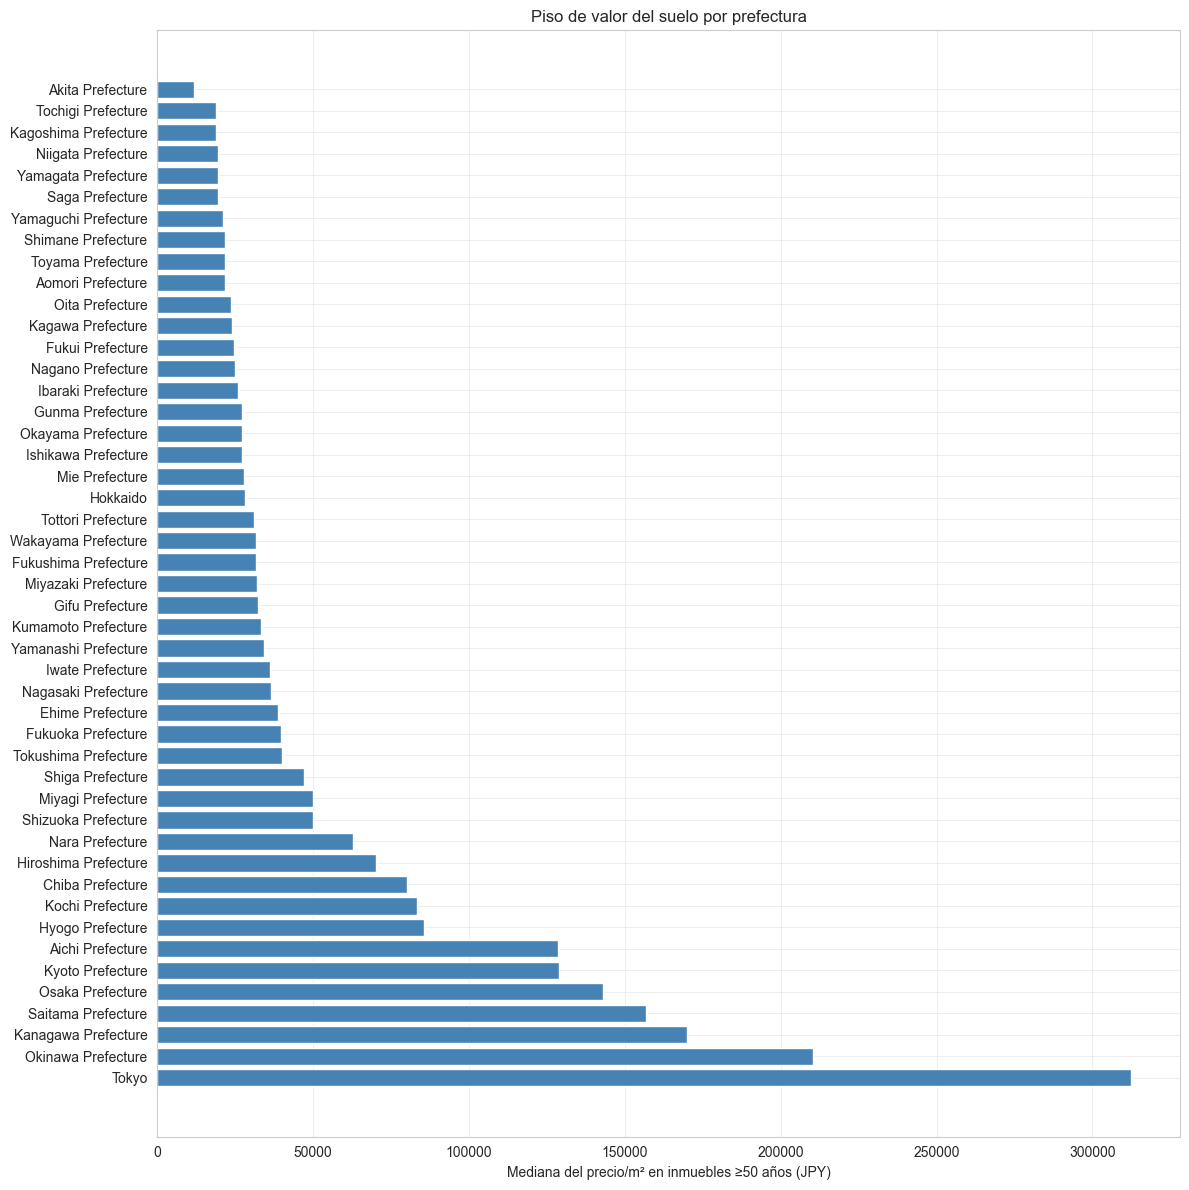

In [10]:
# Agregado a nivel prefectura: mediana del precio/m² en el segmento maduro
land_value_pref = (
    land_value_proxy
    .groupby('Prefecture')
    .agg(
        median_price_per_m2=('price_per_m2', 'median'),
        n_municipios=('Municipality', 'nunique'),
        n_transacciones=('count', 'sum'),
    )
    .reset_index()
    .sort_values('median_price_per_m2')
)
land_value_pref.to_csv(RES_DIR / 'land_value_floor_por_prefectura.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 12))
ax.barh(land_value_pref['Prefecture'], land_value_pref['median_price_per_m2'], color='steelblue')
ax.set_xlabel('Mediana del precio/m² en inmuebles ≥50 años (JPY)')
ax.set_title('Piso de valor del suelo por prefectura')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / '07_land_value_por_prefectura.png', dpi=120, bbox_inches='tight')
plt.show()

## Celda 8 — Conclusiones y recomendación

Combinamos los tres elementos del análisis para producir una recomendación de compra:

1. **Coeficiente de depreciación** del modelo (cuánto cae el precio por año de antigüedad).
2. **Piso de valor del suelo** estimado por prefectura (precio/m² en inmuebles maduros).
3. **Tipo de estructura** óptimo (las que se deprecian más lento conservan mejor su valor).

In [11]:
# 1. Depreciación anual implícita del modelo
print('— Resumen del modelo —')
print(f'  R² (test):          {r2:.4f}')
print(f'  Depreciación anual: {abs(coef_age)*100:.2f}% por año de antigüedad')
print(f'  P-valor BuildingAge: {pval_age:.4e}')

# 2. Edad de convergencia: a partir de qué edad el precio predicho se estabiliza
#    Definimos convergencia como el punto donde el precio cae por debajo del 1.5x
#    del precio en BuildingAge=80 (el suelo asintótico del modelo).
ages_curve = np.arange(0, 81)
X_template = pd.DataFrame([X.median().values] * len(ages_curve), columns=X.columns)
X_template['BuildingAge'] = ages_curve
price_curve = np.exp(model.predict(X_template))
asymptote   = price_curve[-1]
convergence_age = next(
    (a for a, p in zip(ages_curve, price_curve) if p <= 1.5 * asymptote),
    None,
)
print(f'\n— Convergencia al valor del suelo —')
print(f'  Asíntota a 80 años:    {asymptote:>14,.0f} JPY')
print(f'  Edad de convergencia*: {convergence_age} años')
print(f'  *(precio ≤ 1.5× asíntota)')

# 3. Recomendaciones por prefectura: combinar accesibilidad y volumen de mercado
recom = land_value_pref.copy()
recom['rank_accesibilidad'] = recom['median_price_per_m2'].rank()
recom['rank_liquidez']      = recom['n_transacciones'].rank(ascending=False)
recom['score'] = recom[['rank_accesibilidad', 'rank_liquidez']].mean(axis=1)
recom = recom.sort_values('score').reset_index(drop=True)
recom.to_csv(RES_DIR / 'recomendacion_prefecturas.csv', index=False)

print('\n— TOP 10 prefecturas recomendadas (accesibilidad + liquidez) —')
display(recom.head(10))

— Resumen del modelo —
  R² (test):          0.5845
  Depreciación anual: 2.57% por año de antigüedad
  P-valor BuildingAge: 0.0000e+00

— Convergencia al valor del suelo —
  Asíntota a 80 años:         4,527,357 JPY
  Edad de convergencia*: 65 años
  *(precio ≤ 1.5× asíntota)

— TOP 10 prefecturas recomendadas (accesibilidad + liquidez) —


,Prefecture,median_price_per_m2,n_municipios,n_transacciones,rank_accesibilidad,rank_liquidez,score
0,Niigata Prefecture,19444.861215,18,485,4.0,11.0,7.5
1,Yamaguchi Prefecture,20952.380952,11,408,7.0,13.0,10.0
2,Toyama Prefecture,21777.777778,7,314,9.0,16.0,12.5
3,Hokkaido,28125.000000,23,619,20.0,8.0,14.0
4,Nagano Prefecture,25000.000000,11,273,14.0,17.0,15.5
5,Okayama Prefecture,27179.633867,8,321,17.0,15.0,16.0
6,Mie Prefecture,27809.617918,10,396,19.0,14.0,16.5
7,Kagawa Prefecture,23809.523810,5,239,12.0,23.0,17.5
8,Yamagata Prefecture,19493.670886,9,160,5.0,31.0,18.0
9,Oita Prefecture,23703.703704,5,195,11.0,25.0,18.0


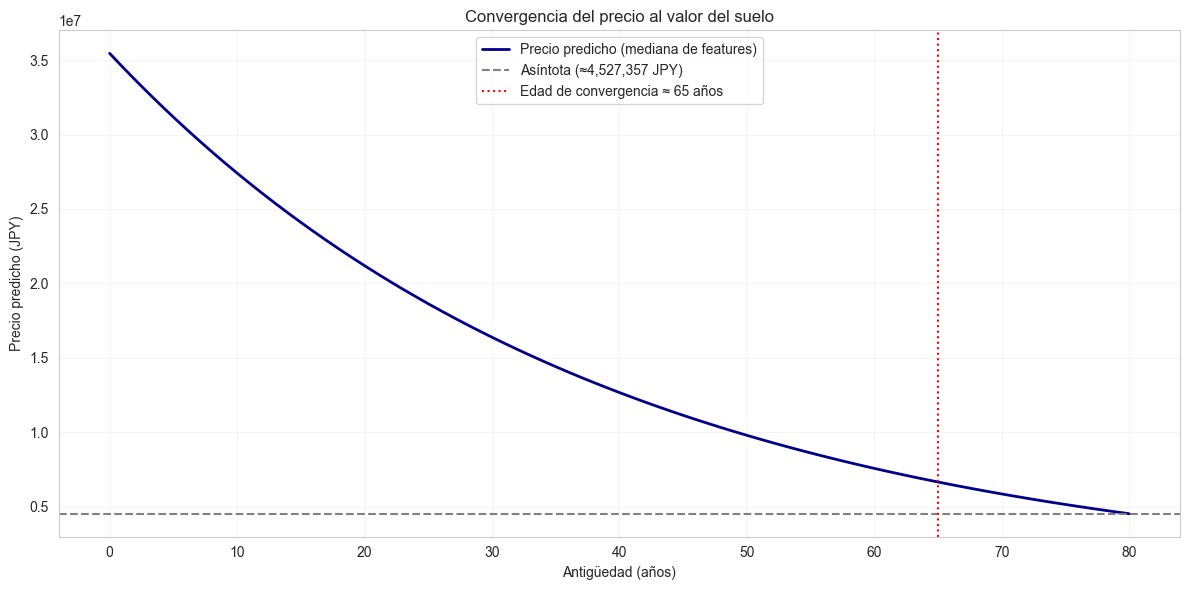

In [12]:
# Export de figura final: curva de depreciación con la edad de convergencia marcada
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ages_curve, price_curve, color='darkblue', linewidth=2, label='Precio predicho (mediana de features)')
ax.axhline(asymptote, linestyle='--', color='gray', label=f'Asíntota (≈{asymptote:,.0f} JPY)')
if convergence_age is not None:
    ax.axvline(convergence_age, linestyle=':', color='red',
               label=f'Edad de convergencia ≈ {convergence_age} años')
ax.set_xlabel('Antigüedad (años)')
ax.set_ylabel('Precio predicho (JPY)')
ax.set_title('Convergencia del precio al valor del suelo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_convergencia.png', dpi=120, bbox_inches='tight')
plt.show()

---

## Salidas generadas

**`figures/`**
- `02_eda_basico.png` — distribuciones y conteos
- `06_depreciacion_por_estructura.png` — curvas por tipo de estructura
- `07_land_value_por_prefectura.png` — ranking de prefecturas
- `08_convergencia.png` — edad de convergencia al valor del suelo

**`results/`**
- `coeficientes_ols.csv` — tabla completa de coeficientes con p-valores e intervalos de confianza
- `land_value_floor_por_municipio.csv` — proxy del valor del suelo por municipio
- `land_value_floor_por_prefectura.csv` — agregado a nivel prefectura
- `recomendacion_prefecturas.csv` — ranking final combinando accesibilidad y liquidez